# Logistic Regression
 P3. Linear regression (trang 47)


In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Đọc dataset

In [12]:
data = pd.read_csv('dataset.csv', encoding='utf-8')
data.head()

,Lương,Thời gian làm việc,Cho vay
0,10,1.0,1
1,5,2.0,1
2,6,1.8,1
3,7,1.0,1
4,8,2.0,1


## Chuẩn bị dữ liệu

In [13]:
X = data[['Lương', 'Thời gian làm việc']].values
y = data['Cho vay'].values

# thêm bias
X_bias = np.c_[np.ones(len(X)), X]

print(X_bias[:5])

[[ 1.  10.   1. ]
 [ 1.   5.   2. ]
 [ 1.   6.   1.8]
 [ 1.   7.   1. ]
 [ 1.   8.   2. ]]


## Hàm sigmoid

In [14]:
def sigmoid(z):
    return 1/(1+np.exp(-z))

## Khởi tạo tham số

In [15]:
w = np.zeros(X_bias.shape[1])

lr = 0.01
epochs = 2000

## Training Logistic Regression

In [16]:
for epoch in range(epochs):
    for i in range(len(X_bias)):

        z = np.dot(w, X_bias[i])
        y_hat = sigmoid(z)

        error = y[i] - y_hat

        w = w + lr * error * X_bias[i]

print('Weights:', w)

Weights: [-10.64991773   0.97327131   4.84400383]


## Vẽ dữ liệu và Decision Boundary

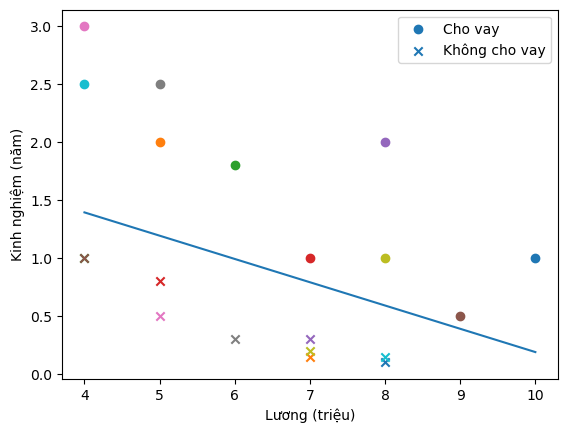

In [17]:
# Vẽ dữ liệu

for i in range(len(X)):
    if y[i] == 1:
        plt.scatter(X[i,0], X[i,1], marker="o", label="Cho vay" if i==0 else "")
    else:
        plt.scatter(X[i,0], X[i,1], marker="x", label="Không cho vay" if i==10 else "")

# Vẽ decision boundary

x_values = np.linspace(min(X[:,0]), max(X[:,0]), 100)

y_values = -(w[0] + w[1]*x_values) / w[2]

plt.plot(x_values, y_values)

plt.xlabel("Lương (triệu)")
plt.ylabel("Kinh nghiệm (năm)")
plt.legend()

plt.show()